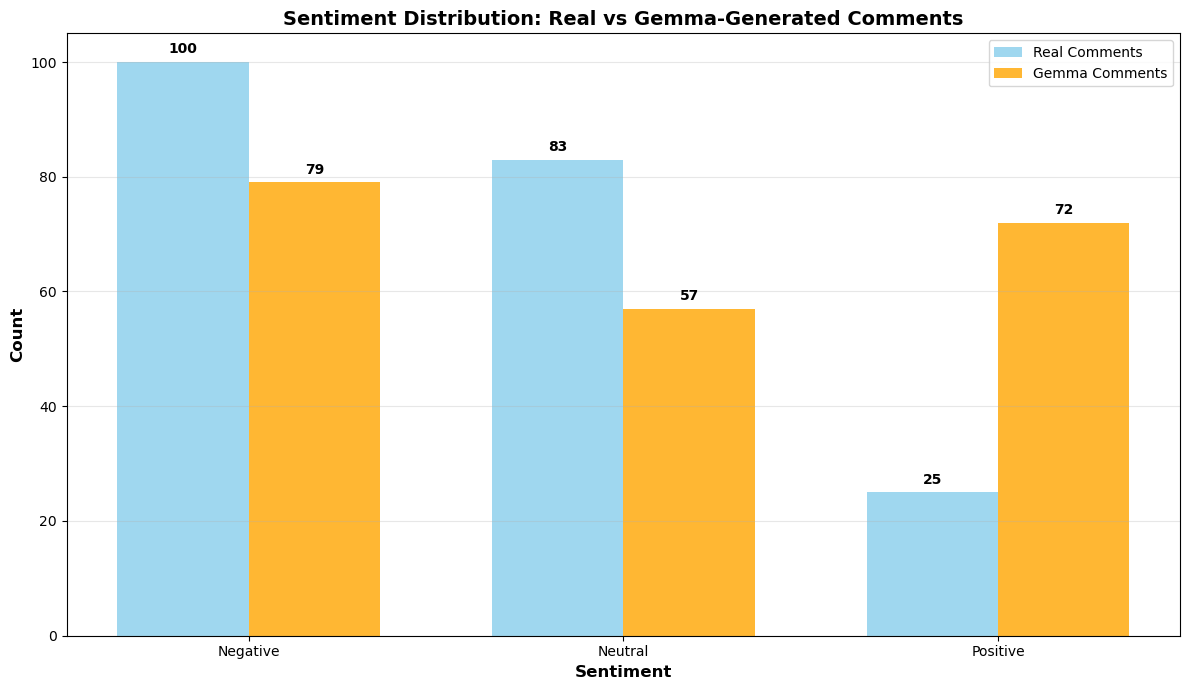

Real Comments:
  Negative: 100 (48.1%)
  Neutral: 83 (39.9%)
  Positive: 25 (12.0%)

Gemma Comments:
  Negative: 79 (38.0%)
  Neutral: 57 (27.4%)
  Positive: 72 (34.6%)

Total Real Comments: 208
Total Gemma Comments: 208

--- Jensen-Shannon Metrics ---
JS Distance:    0.1933  (range: 0–1)
JS Divergence:  0.0374  (range: 0–1, = JSD²)
Interpretation: Excellent match


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

# Load both datasets
real_df = pd.read_csv(r'C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\multiloss\multiloss_sentiment_resultsv3.csv')
llama_df = pd.read_csv(r'C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\multiloss\multiloss_sentiment_resultsv3.csv')  # ← fix this path!

# Map numeric sentiment to text labels
sentiment_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Count occurrences for both datasets
real_counts = real_df['Real Sentiment'].value_counts()
llama_counts = llama_df['Sentiment over comment from models'].map(sentiment_map).value_counts()

# Define desired label order
desired_order = ['Negative', 'Neutral', 'Positive']

# Prepare data for grouped bar plot
real_values = np.array([real_counts.get(label, 0) for label in desired_order], dtype=float)
llama_values = np.array([llama_counts.get(label, 0) for label in desired_order], dtype=float)

# Convert counts to probability distributions
real_probs = real_values / real_values.sum()
llama_probs = llama_values / llama_values.sum()

# Compute JS Divergence (scipy returns JS Distance; square it for divergence)
js_distance = jensenshannon(real_probs, llama_probs)
js_divergence = js_distance ** 2  # JS divergence ∈ [0, 1]

# Set up the plot
x = np.arange(len(desired_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Create grouped bars
bars1 = ax.bar(x - width/2, real_values, width, label='Real Comments', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, llama_values, width, label='Gemma Comments', color='orange', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
ax.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Distribution: Real vs Gemma-Generated Comments', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(desired_order)
ax.legend()
ax.grid(axis='y', alpha=0.3)



plt.tight_layout()
plt.show()

# Print summary statistics
print("Real Comments:")
for sentiment, count, prob in zip(desired_order, real_values, real_probs):
    print(f"  {sentiment}: {int(count)} ({prob*100:.1f}%)")

print("\nGemma Comments:")
for sentiment, count, prob in zip(desired_order, llama_values, llama_probs):
    print(f"  {sentiment}: {int(count)} ({prob*100:.1f}%)")

print(f"\nTotal Real Comments: {int(real_values.sum())}")
print(f"Total Gemma Comments: {int(llama_values.sum())}")

print(f"\n--- Jensen-Shannon Metrics ---")
print(f"JS Distance:    {js_distance:.4f}  (range: 0–1)")
print(f"JS Divergence:  {js_divergence:.4f}  (range: 0–1, = JSD²)")
print(f"Interpretation: {'Excellent match' if js_divergence < 0.05 else 'Good match' if js_divergence < 0.1 else 'Moderate divergence' if js_divergence < 0.2 else 'High divergence'}")

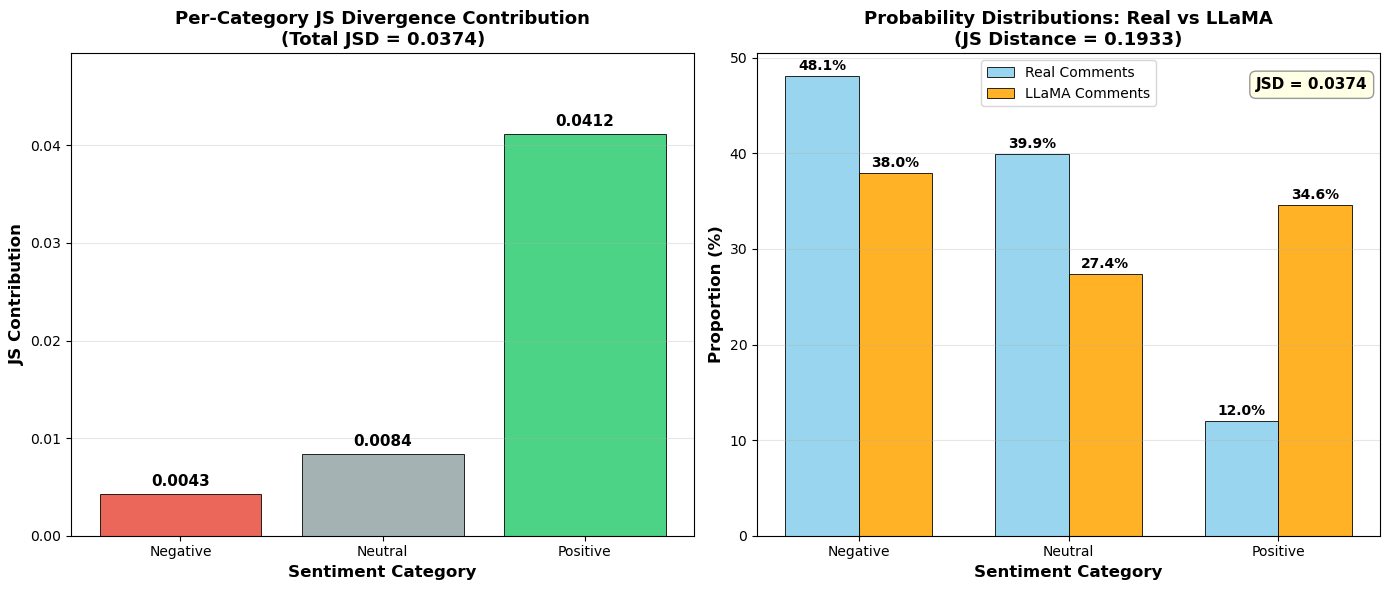

In [6]:
# --- JS Divergence Per-Category Contribution Plot ---

# Compute per-category JS contributions manually
def js_contributions(p, q):
    m = 0.5 * (p + q)
    # Avoid log(0)
    kl_pm = np.where(p > 0, p * np.log2(p / m), 0)
    kl_qm = np.where(q > 0, q * np.log2(q / m), 0)
    return 0.5 * kl_pm + 0.5 * kl_qm

contributions = js_contributions(real_probs, llama_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Per-category contribution bar chart ---
colors = ['#e74c3c', '#95a5a6', '#2ecc71']  # red, gray, green for Neg/Neu/Pos
bars = axes[0].bar(desired_order, contributions, color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, contributions):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].set_xlabel('Sentiment Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('JS Contribution', fontsize=12, fontweight='bold')
axes[0].set_title(f'Per-Category JS Divergence Contribution\n(Total JSD = {js_divergence:.4f})', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(contributions) * 1.2)

# --- Right: Probability distribution comparison ---
x = np.arange(len(desired_order))
width = 0.35

bars1 = axes[1].bar(x - width/2, real_probs * 100, width, label='Real Comments', color='skyblue', alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = axes[1].bar(x + width/2, llama_probs * 100, width, label='LLaMA Comments', color='orange', alpha=0.85, edgecolor='black', linewidth=0.7)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.3,
                     f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

axes[1].set_xlabel('Sentiment Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Probability Distributions: Real vs LLaMA\n(JS Distance = {js_distance:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(desired_order)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[1].text(0.98, 0.95,
             f'JSD = {js_divergence:.4f}',
             transform=axes[1].transAxes, fontsize=11, fontweight='bold',
             ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('js_divergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

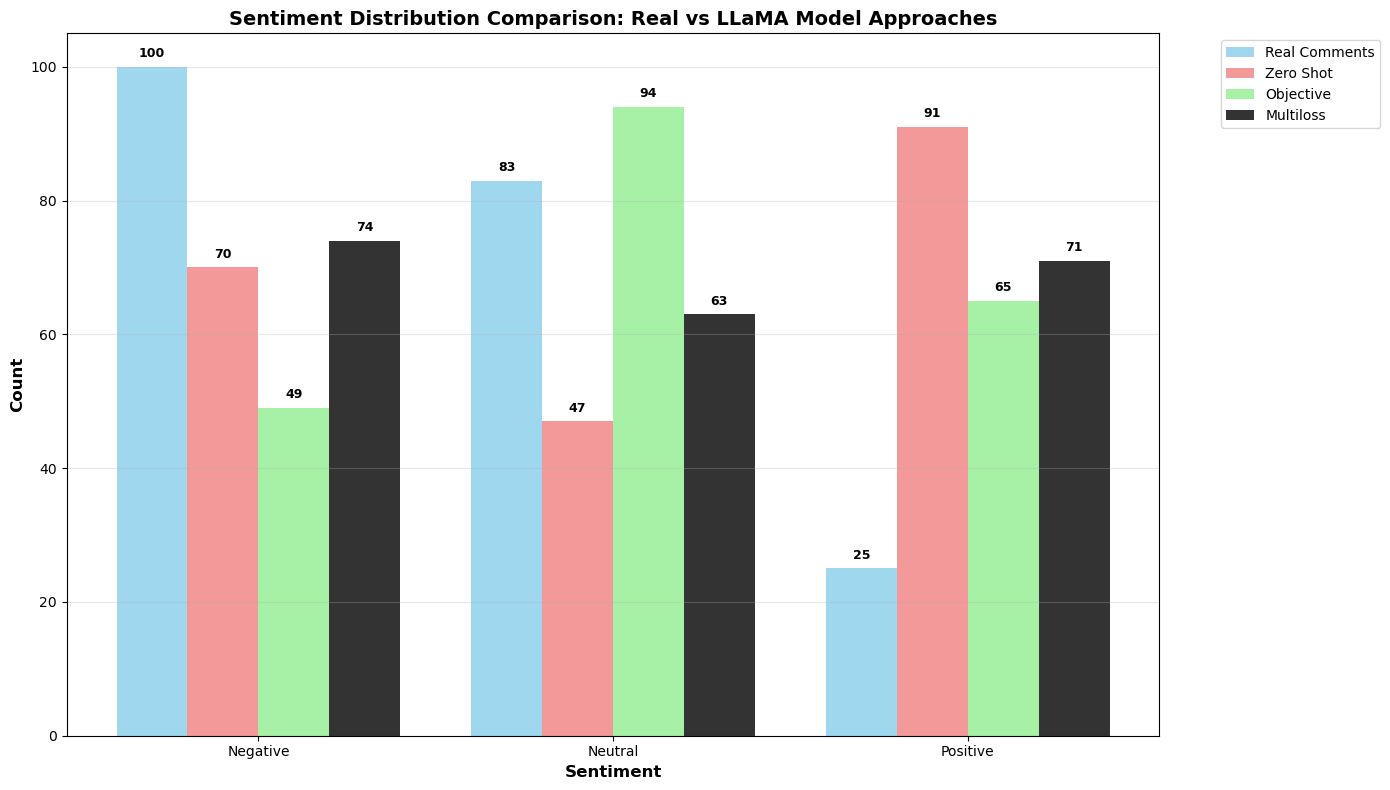

SENTIMENT DISTRIBUTION SUMMARY

Real Comments:
  Negative: 100 (48.1%)
  Neutral: 83 (39.9%)
  Positive: 25 (12.0%)
  Total: 208

Zero Shot:
  Negative: 70 (33.7%)
  Neutral: 47 (22.6%)
  Positive: 91 (43.8%)
  Total: 208

Objective:
  Negative: 49 (23.6%)
  Neutral: 94 (45.2%)
  Positive: 65 (31.2%)
  Total: 208

Multiloss:
  Negative: 74 (35.6%)
  Neutral: 63 (30.3%)
  Positive: 71 (34.1%)
  Total: 208

PERCENTAGE COMPARISON
Sentiment    Real     Zero Shot Objective Multiloss
------------------------------------------------------------
Negative       48.1%   23.6%   35.6%
Neutral        39.9%   45.2%   30.3%
Positive       12.0%   31.2%   34.1%


In [2]:
# Create comprehensive bar chart comparing all models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
real_df = pd.read_csv(r'C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\LLAMA_3.2_3B_Instruct\sentiment_results.csv')
zero_shot = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\LLAMA_3.2_3B_Instruct\sentiment_results.csv")
objective= pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v30_objectivee_buurman_new_data\sentiment_results.csv")
multiloss = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v39_v38_same_customwt_changed\sentiment_results.csv")


# Map numeric sentiment to text labels
sentiment_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Count occurrences for all datasets
real_counts = real_df['Real Sentiment'].value_counts()
zero_shot_counts = zero_shot['Sentiment over comment from models'].map(sentiment_map).value_counts()

objective_counts = objective['Sentiment over comment from models'].map(sentiment_map).value_counts()
multiloss_counts = multiloss['Sentiment over comment from models'].map(sentiment_map).value_counts()

# Define desired label order
desired_order = ['Negative', 'Neutral', 'Positive']

# Prepare data for grouped bar plot
real_values = [real_counts.get(label, 0) for label in desired_order]
zero_shot_values = [zero_shot_counts.get(label, 0) for label in desired_order]
objective_values = [objective_counts.get(label, 0) for label in desired_order]
multiloss_values = [multiloss_counts.get(label, 0) for label in desired_order]

# Set up the plot
x = np.arange(len(desired_order))
width = 0.2  # Narrower bars to fit 4 groups

fig, ax = plt.subplots(figsize=(14, 8))

# Create grouped bars
bars1 = ax.bar(x - 1.5*width, real_values, width, label='Real Comments', color='skyblue', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, zero_shot_values, width, label='Zero Shot', color='lightcoral', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, objective_values, width, label='Objective', color='lightgreen', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, multiloss_values, width, label='Multiloss', color='black', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Customize the plot
ax.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Distribution Comparison: Real vs LLaMA Model Approaches', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(desired_order)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive summary statistics
print("SENTIMENT DISTRIBUTION SUMMARY")
print("=" * 60)

datasets = [
    ("Real Comments", real_values),
    ("Zero Shot", zero_shot_values),
    ("Objective", objective_values),
    ("Multiloss", multiloss_values)
]

for dataset_name, values in datasets:
    print(f"\n{dataset_name}:")
    total = sum(values)
    for sentiment, count in zip(desired_order, values):
        percentage = (count / total) * 100 if total > 0 else 0
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")
    print(f"  Total: {total}")

# Create percentage comparison
print(f"\n{'PERCENTAGE COMPARISON'}")
print("=" * 60)
print(f"{'Sentiment':<12} {'Real':<8} {'Zero Shot':<8} {'Objective':<8} {'Multiloss':<8}")
print("-" * 60)

for i, sentiment in enumerate(desired_order):
    real_pct = (real_values[i] / sum(real_values)) * 100 if sum(real_values) > 0 else 0
    zero_shot_pct = (zero_shot_values[i] / sum(zero_shot_values)) * 100 if sum(zero_shot_values) > 0 else 0
    objective_pct = (objective_values[i] / sum(objective_values)) * 100 if sum(objective_values) > 0 else 0
    multiloss_pct = (multiloss_values[i] / sum(multiloss_values)) * 100 if sum(multiloss_values) > 0 else 0
    
    print(f"{sentiment:<12} {real_pct:>6.1f}% {objective_pct:>6.1f}% {multiloss_pct:>6.1f}%")

Couldn't import dot_parser, loading of dot files will not be possible.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\20245179\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


442


Device set to use cpu
Device set to use cpu
Device set to use cpu
100%|██████████| 442/442 [02:19<00:00,  3.16it/s]


In [3]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import pandas as pd

# Probability distributions over [Negative, Neutral, Positive]
real_arr      = np.array(real_values,      dtype=float)
zero_shot_arr = np.array(zero_shot_values, dtype=float)
objective_arr = np.array(objective_values, dtype=float)
multiloss_arr = np.array(multiloss_values, dtype=float)

real_probs      = real_arr      / real_arr.sum()
zero_shot_probs = zero_shot_arr / zero_shot_arr.sum()
objective_probs = objective_arr / objective_arr.sum()
multiloss_probs = multiloss_arr / multiloss_arr.sum()

gen_models = [
    ("Zero Shot",       zero_shot_probs, zero_shot_arr),
    ("Objective (v30)", objective_probs, objective_arr),
    ("Multiloss (v39)", multiloss_probs, multiloss_arr),
]

rows = []
for model_name, gen_probs, gen_vals in gen_models:
    js_dist = jensenshannon(real_probs, gen_probs)
    js_div  = js_dist ** 2

    row = {"Model": model_name, "JS Distance": round(js_dist, 6), "JS Divergence (²)": round(js_div, 6)}
    for i, sentiment in enumerate(desired_order):
        row[f"Real % {sentiment}"]  = round(real_probs[i] * 100, 1)
        row[f"Gen % {sentiment}"]   = round(gen_probs[i]  * 100, 1)
        row[f"Δ {sentiment}"]       = round(abs(gen_probs[i] - real_probs[i]) * 100, 1)

    row["Interpretation"] = (
        "Excellent match"    if js_div  < 0.05 else
        "Good match"         if js_div  < 0.10 else
        "Moderate divergence" if js_div < 0.20 else
        "High divergence"
    )
    rows.append(row)

js_table = pd.DataFrame(rows).set_index("Model")

print("=" * 80)
print("JENSEN-SHANNON DIVERGENCE: SENTIMENT DISTRIBUTION vs REAL COMMENTS")
print("=" * 80)
print(js_table.to_string())
print()
print("Note: JS Distance ∈ [0, 1] — 0 = identical, 1 = completely different")
print("      JS Divergence = JS Distance²")

js_table

JENSEN-SHANNON DIVERGENCE: SENTIMENT DISTRIBUTION vs REAL COMMENTS
                 JS Distance  JS Divergence (²)  Real % Negative  Gen % Negative  Δ Negative  Real % Neutral  Gen % Neutral  Δ Neutral  Real % Positive  Gen % Positive  Δ Positive   Interpretation
Model                                                                                                                                                                                               
Zero Shot           0.257858           0.066491             48.1            33.7        14.4            39.9           22.6       17.3             12.0            43.8        31.7       Good match
Objective (v30)     0.210634           0.044367             48.1            23.6        24.5            39.9           45.2        5.3             12.0            31.2        19.2  Excellent match
Multiloss (v39)     0.188688           0.035603             48.1            35.6        12.5            39.9           30.3        9.6           

,JS Distance,JS Divergence (²),Real % Negative,Gen % Negative,Δ Negative,Real % Neutral,Gen % Neutral,Δ Neutral,Real % Positive,Gen % Positive,Δ Positive,Interpretation
Model,,,,,,,,,,,,
Zero Shot,0.257858,0.066491,48.1,33.7,14.4,39.9,22.6,17.3,12.0,43.8,31.7,Good match
Objective (v30),0.210634,0.044367,48.1,23.6,24.5,39.9,45.2,5.3,12.0,31.2,19.2,Excellent match
Multiloss (v39),0.188688,0.035603,48.1,35.6,12.5,39.9,30.3,9.6,12.0,34.1,22.1,Excellent match
